In [2]:
import seaborn as sns 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
df=pd.read_csv("/Users/mayurimamdi/Downloads/customer_subscription_churn_usage_patterns.csv")

In [4]:
df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes


In [5]:
df.shape

(2800, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 218.9+ KB


In [7]:
df['plan_type'].value_counts()

plan_type
Premium     944
Standard    933
Basic       923
Name: count, dtype: int64

In [8]:
df['monthly_fee'].value_counts()

monthly_fee
699    944
399    933
199    923
Name: count, dtype: int64

In [9]:
df['churn'].value_counts()

churn
Yes    1605
No     1195
Name: count, dtype: int64

In [10]:
df['signup_year']=df['signup_date'].str.split('-').str[0].astype(int)

In [11]:
df['signup_month']=df['signup_date'].str.split('-').str[1].astype(int)

In [12]:
df['day']=df['signup_date'].str.split('-').str[2].astype(int)

In [13]:
df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,signup_year,signup_month,day
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes,2023,4,15
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes,2023,8,27
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes,2023,10,12
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes,2023,12,11
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes,2023,2,14


## EDA

In [14]:
#df['churn']=df['churn'].map({'Yes':1, 'No':0})

In [15]:
#df['plan_type']=df['plan_type'].map({'Premium':3, 'Standard':2, 'Basic':1})

In [16]:
df['signup_year'].unique()

array([2023, 2024])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   object 
 10  signup_year             2800 non-null   int64  
 11  signup_month            2800 non-null   int64  
 12  day                     2800 non-null   int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 284.5+ KB


In [38]:
df['signup_year'].unique()

array([2023, 2024])

In [34]:
res=df.groupby('signup_month')['churn'].value_counts().reset_index(name='count')


<Axes: xlabel='signup_month', ylabel='count'>

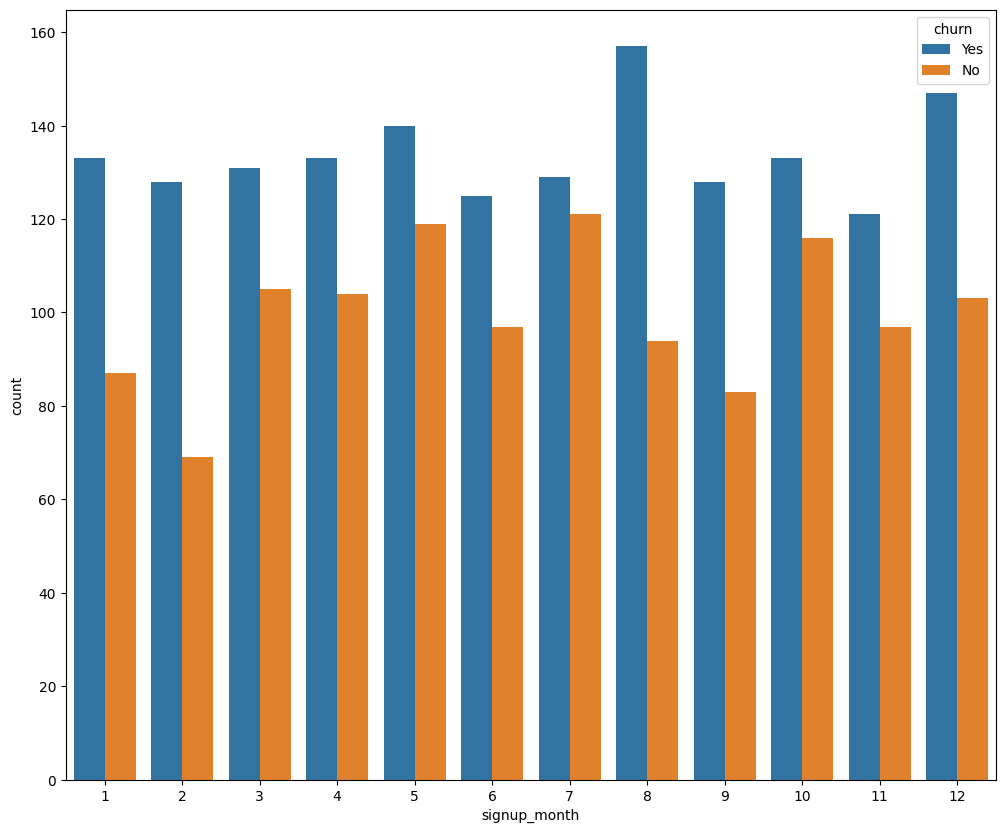

In [37]:
plt.figure(figsize=(12,10))
sns.barplot(data=res, x='signup_month',y='count',hue='churn')

#### Observation: August month is when the churn was more, and in february the churn was less

In [40]:
year_df=df.groupby('signup_year')['churn'].value_counts().reset_index(name='count')

<Axes: xlabel='signup_year', ylabel='count'>

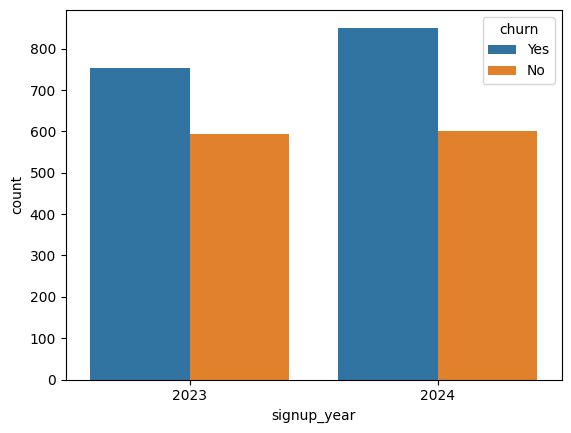

In [41]:
sns.barplot(data=year_df, x='signup_year', y='count', hue='churn' )

#### There is more churn in 2024 than 2023

In [42]:
df['signup_month'].unique()

array([ 4,  8, 10, 12,  2,  1,  3, 11,  9,  6,  7,  5])

In [47]:
df[(df['signup_month']==2) &(df['signup_year']==2024)].groupby('signup_month')['churn'].value_counts().reset_index(name='count')

,signup_month,churn,count
0,2,Yes,58
1,2,No,27


In [46]:
df[(df['signup_month']==8) &(df['signup_year']==2024)].groupby('signup_month')['churn'].value_counts().reset_index(name='count')

,signup_month,churn,count
0,8,Yes,91
1,8,No,51


In [48]:
df[(df['signup_month']==2) &(df['signup_year']==2023)].groupby('signup_month')['churn'].value_counts().reset_index(name='count')

,signup_month,churn,count
0,2,Yes,70
1,2,No,42


In [49]:
df[(df['signup_month']==8) &(df['signup_year']==2023)].groupby('signup_month')['churn'].value_counts().reset_index(name='count')

,signup_month,churn,count
0,8,Yes,66
1,8,No,43


#### Observation : august month in year 2024 is when the churn was more and also lowest churn was in february year 2024

In [62]:
days=df[(df['signup_month']==2) &(df['signup_year']==2024)].groupby('day')['churn'].value_counts().reset_index(name='count')

/var/folders/ph/wg0wr1gs4qs24s_3z3tp0pj80000gn/T/ipykernel_49891/2093922542.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=days, x='day', y='count',hue='churn', ci=None)


<Axes: xlabel='day', ylabel='count'>

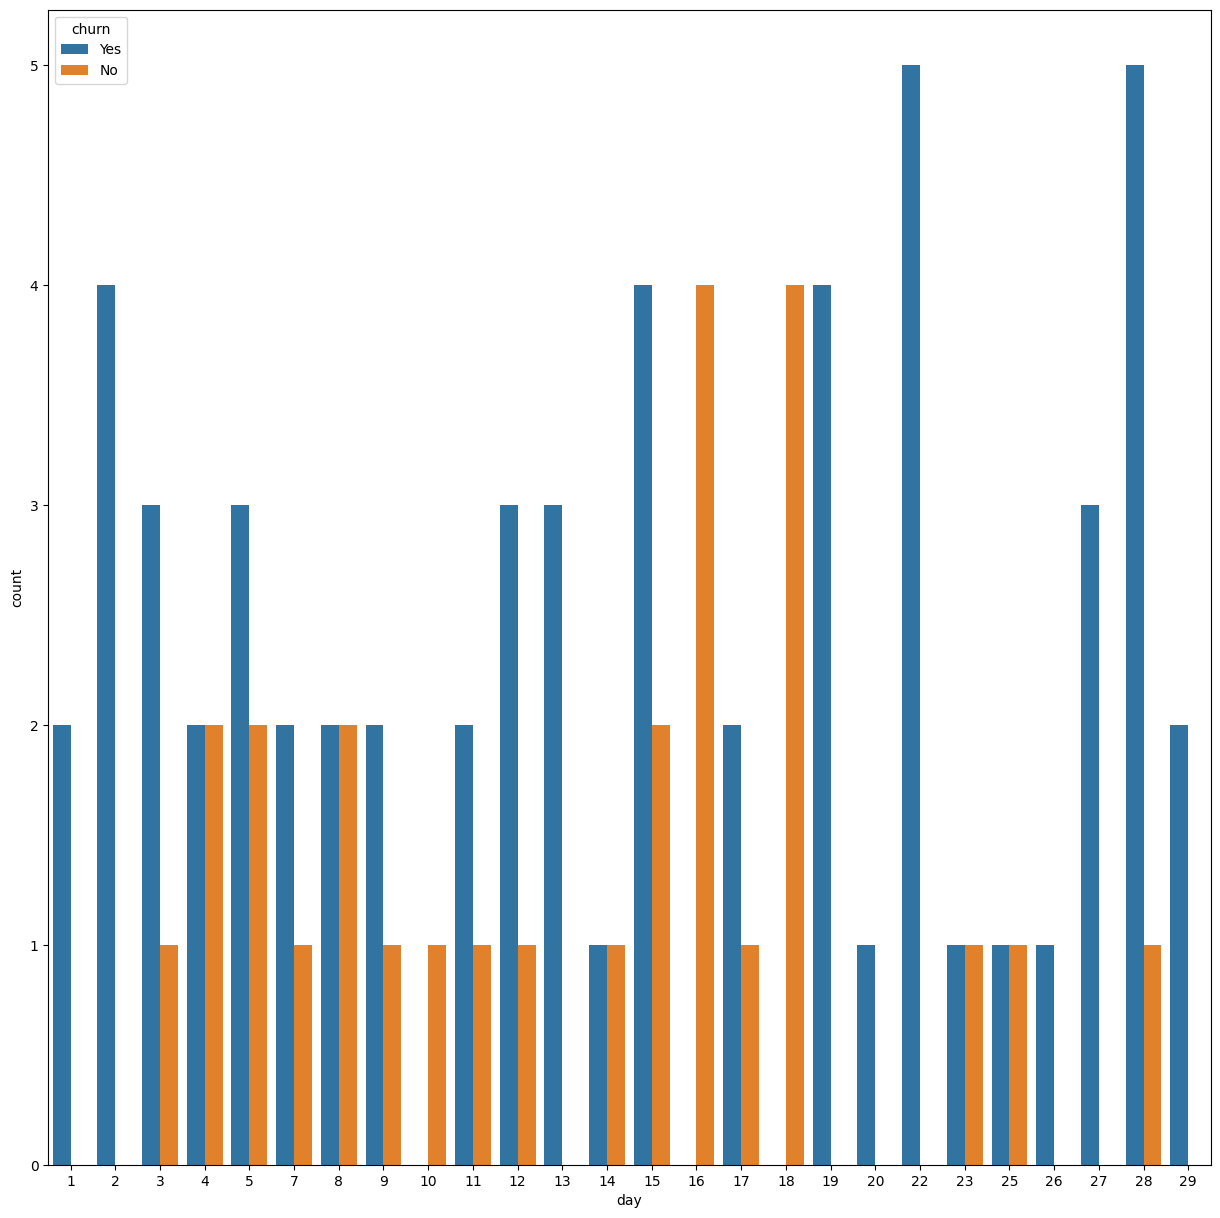

In [63]:
plt.figure(figsize=(15,15))
sns.barplot(data=days, x='day', y='count',hue='churn', ci=None)

In [59]:
aug_days=df[(df['signup_month']==8) & (df['signup_year']==2024)].groupby('day')['churn'].value_counts().reset_index(name='count')

/var/folders/ph/wg0wr1gs4qs24s_3z3tp0pj80000gn/T/ipykernel_49891/1123012493.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=aug_days, x='day', y='count', hue='churn', ci=None)


<Axes: xlabel='day', ylabel='count'>

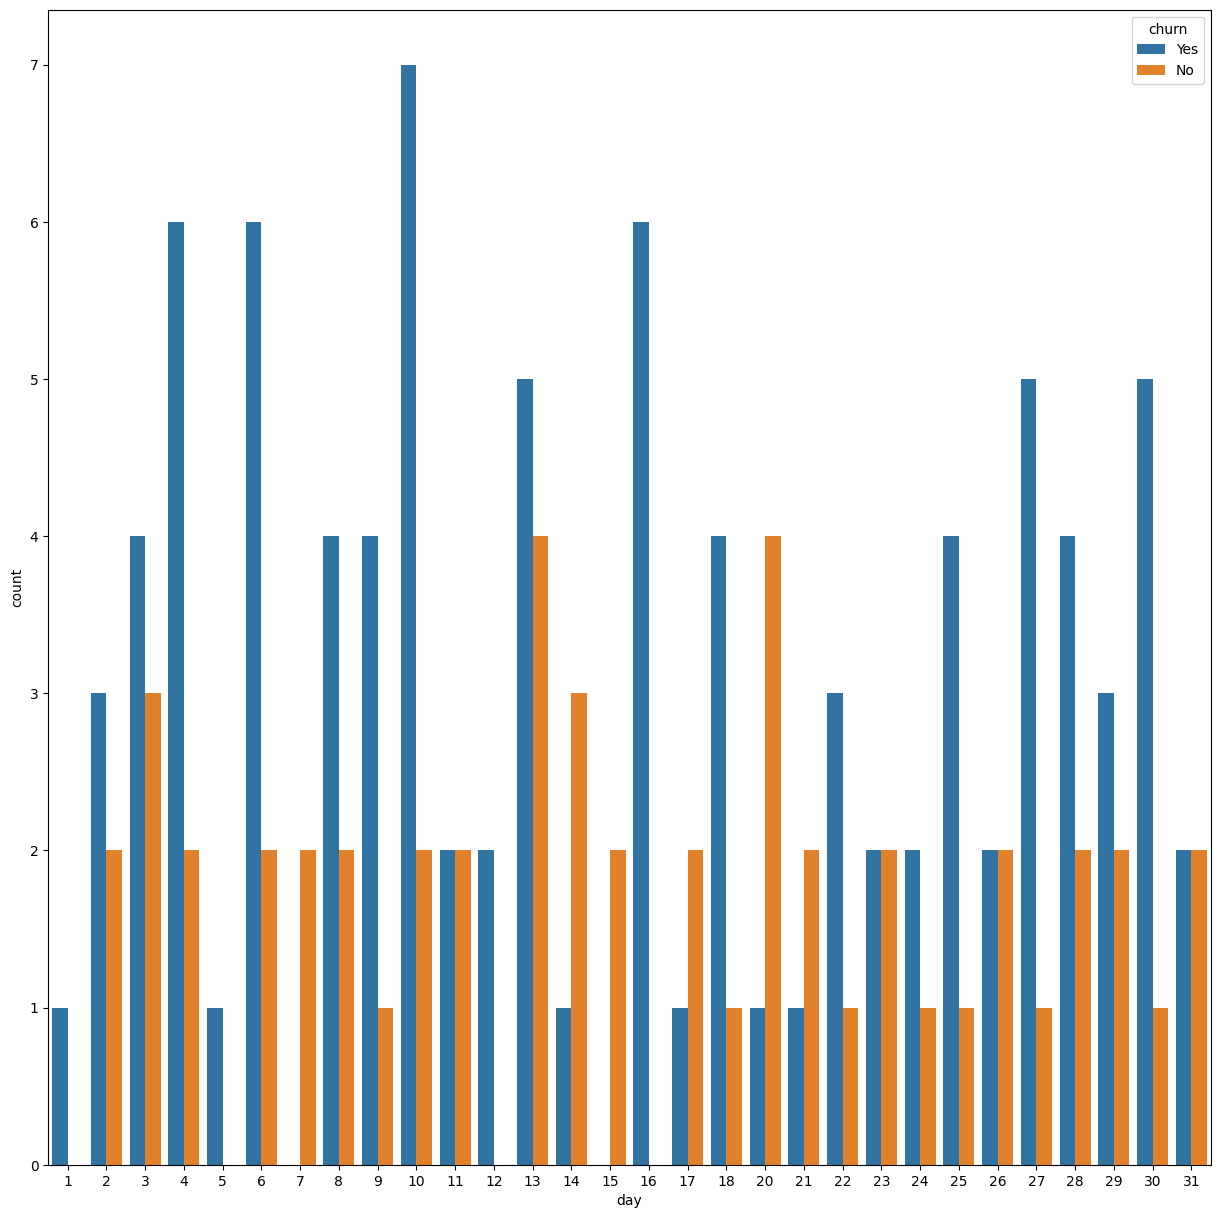

In [61]:
plt.figure(figsize=(15,15))
sns.barplot(data=aug_days, x='day', y='count', hue='churn', ci=None)